In [1]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

import cliffordep

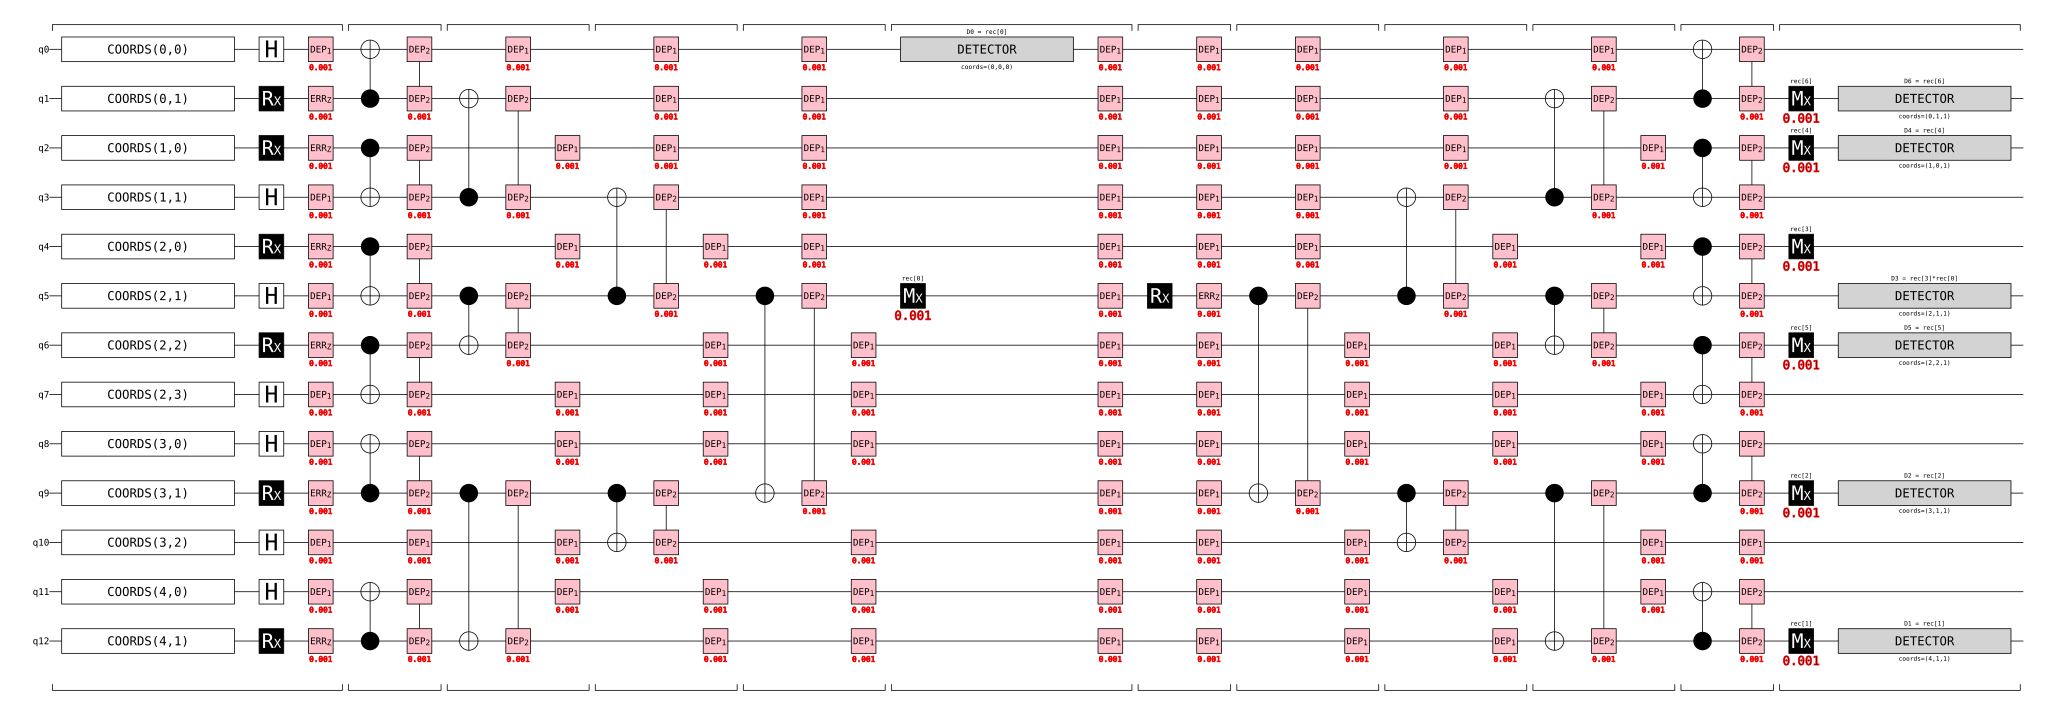

In [2]:
circuit = cliffordep.circuits.D3DoubleCatCheckA6()
noise_strength = 1e-3
noisy_circuit = cliffordep.noise.uniformly_depolarize(circuit.INNER_CIRCUIT, noise_level=noise_strength)
# remove last layer of depolarizing noise
noisy_circuit = noisy_circuit[:-1]
noisy_circuit.diagram('timeline-svg')

In [3]:
cultiv_circuit = cliffordep.CultivationCircuit(
    noisy_circuit=noisy_circuit,
    data_indices=circuit.DATA_INDICES,
    stabilizer_generators=circuit.STABILIZER_GENERATORS,
    logical_x=circuit.LOGICAL_X,
    logical_z=circuit.LOGICAL_Z,
)

In [ ]:
# takes 6 s
fault_combinations = cultiv_circuit.get_undetected_fault_combinations(
    max_order=3,
    print_progress=True,
)

Finished enumerating all faults. Found 19 distinct syndromes.
Finding undetected combinations of length 0...
Done. They lead to 1 distinct effects.
Finding undetected combinations of length 1...
Done. They lead to 32 distinct effects.
Finding undetected combinations of length 2...
Done. They lead to 414 distinct effects.
Finding undetected combinations of length 3...
Done. They lead to 2544 distinct effects.


In [6]:
# takes 4 s
states: list[Literal['T', 'S', 'Z']] = ['T', 'S', 'Z']
kept_strings = {state: cultiv_circuit.get_kept_strings(
    fault_combinations,
    cultivated_state=state,
    print_progress=True,
) for state in states}

T state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 9 (4) effects are stabilized and lead to identity (error).
For order 3, 68 (65) effects are stabilized and lead to identity (error).
S state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 7 (0) effects are stabilized and lead to identity (error).
For order 3, 16 (24) effects are stabilized and lead to identity (error).
Z state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 7 (0) effects are stabilized and lead to identity (error).
For order 3, 16 (24) effects are stabilized and lead to identity (error).


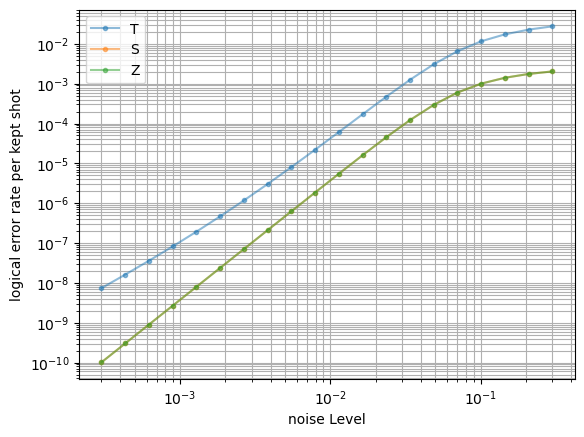

In [7]:
noise_levels = np.geomspace(3e-4, 3e-1, 20)
for state, strings in kept_strings.items():
    y = [cliffordep.error_rate_per_kept_shot(strings, noise_level=noise_level)
        for noise_level in noise_levels]
    plt.plot(noise_levels, y, marker='.', label=state, alpha=0.5)
plt.loglog()
plt.xlabel('noise Level')
plt.ylabel('logical error rate per kept shot')
plt.grid(True, which='both')
plt.legend()
plt.show()